#Download & Move data to correct location

In [ ]:
# DO THIS FIRST BECAUSE WE NEED NUMPY 1.26.4 FOR TRANSFORMERS-LENS
# AFTER THAT, COMMENT THEM AND RERUN

#!pip uninstall -q numpy==2.0.2
#!pip install -q numpy==1.26.4

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git
!git clone -q https://github.com/Anshler/RAM-cocomix-backup.git
%mv RAM/projects/cocomix/* /content/
%rm -rf RAM

!pip install flash-attn --no-build-isolation
!pip install -q transformers transformer-lens opendatasets rouge-metric pycocoevalcap accelerate hydra-core bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.2 MB/s eta 0:00:00
fatal: destination path 'RAM' already exists and is not an empty directory.
    

In [ ]:
if is_flash_attn_2_available():
  print('flash_attn_2_available')
  from transformers.modeling_flash_attention_utils import _flash_attention_forward

# Setup Constant

In [ ]:
import os
import opendatasets as od
import shutil
import torch
import torch.nn as nn
import clip
import pickle
import pandas as pd
import numpy as np
import json
import sys
import hydra
from PIL import Image
from tqdm import tqdm, trange
from torch.nn import functional as nnf
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from enum import Enum
from transformers import AutoConfig, GPT2Tokenizer, GPT2LMHeadModel, AutoTokenizer, get_linear_schedule_with_warmup
from typing import Tuple, Optional, Union, List
from google.colab import files
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from utils import Logger, set_random_seed
from bert_score import score as bert_score

In [ ]:
#@title Global functions
# Normal clip
def CLIP(name : str = 'ViT-L/14'):
  clip_model, preprocess = clip.load(name=name, device='cuda')
  return clip_model, preprocess

In [ ]:
dataset_name = 'Flickr30K'
#od.download("https://www.kaggle.com/datasets/eeshawn/flickr30k")

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# cd to the project folder, remember to create the folder before this
full_path = '/content/gdrive/My Drive/FSB_capstone/Flickr30K'
os.chdir(full_path)
full_path

'/content/gdrive/My Drive/FSB_capstone/Flickr30K'

#Step 1: Create Dataset Embedding

In [ ]:
# Embedd all image features to img_embedding_train.pkl and img_embedding_test.pkl
def ClipEmbedding():
    out_path_train = f"{full_path}/img_embedding_train.pkl"
    out_path_test = f"{full_path}/img_embedding_test.pkl"
    clip_model, preprocess = CLIP()

    data = pd.read_csv('/content/flickr30k/captions.txt', delimiter=",")
    data = data.rename(columns={'image_name': 'image', 'comment': 'caption'})[['image','caption']]

    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption_number'] = data.index % 5
    data = data.to_dict(orient='records')

    data_train = data[:-5000]
    data_test = data[-5000:] # Last 1000 images (5000 captions) for testing

    def get_embedding(data, out_path):
      device = 'cuda'
      print("%0d captions loaded from json " % len(data))
      all_embeddings = []
      all_captions = []

      current_prefix = 0
      for i in tqdm(range(len(data))):
          d = data[i]
          img_id = d["image"]
          filename = "/content/flickr30k/flickr30k_images/%s" % img_id

          # only process first of 5 identical images
          if d['caption_number'] == 0:
            # Extract features
            image = preprocess(Image.open(filename)).unsqueeze(0).to(device)
            with torch.no_grad(), torch.cuda.amp.autocast():
                prefix = clip_model.encode_image(image)
            current_prefix = prefix
          else:
            prefix = current_prefix

          # Save the index of every picture, original code did so, idk why
          d["clip_embedding"] = i

          all_embeddings.append(prefix)
          all_captions.append(d)
          # Checkpoint once every 10000 captions, just in case
          if (i + 1) % 10000 == 0:
              with open(out_path, 'wb') as f:
                  pickle.dump({"clip_embedding": torch.cat(all_embeddings, dim=0), "caption": all_captions}, f)

      with open(out_path, 'wb') as f:
          pickle.dump({"clip_embedding": torch.cat(all_embeddings, dim=0), "caption": all_captions}, f)

      print('Done')
      print("%0d embeddings saved " % len(all_embeddings))

    get_embedding(data_train, out_path_train)
    get_embedding(data_test, out_path_test)


#if __name__ == '__main__':
    #ClipEmbedding()


# Step 2: Setup Model

In [ ]:
from dataclasses import dataclass

import blobfile as bf
import models.sparse_autoencoder as sparse_autoencoder
import torch
import torch.nn as nn
import transformer_lens
from torch.nn import CrossEntropyLoss
from transformer_lens import ActivationCache


class TransformerLensSAE(nn.Module):
    def __init__(self, layer_index=6, location="resid_post_mlp"):
        super().__init__()

        # define sparse autoencoder
        self.layer_index = layer_index
        base_model = transformer_lens.HookedTransformer.from_pretrained("gpt2")

        self.base_model = base_model
        self.base_model.eval()

        self.transformer_lens_loc = {
            "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
            "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
            "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
            "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
            "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
        }[location]

        with bf.BlobFile(
            sparse_autoencoder.paths.v5_32k(location, layer_index), mode="rb"
        ) as f:
            state_dict = torch.load(f)
            autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)

        self.autoencoder = autoencoder

    def get_cache_fwd_and_bwd(self, embeds, labels, new_act=None):
        # filter_not_qkv_input = lambda name: "_input" not in name

        self.base_model.reset_hooks()
        cache = {}

        def forward_cache_hook(act, hook):
            if new_act is not None:
                cache[hook.name] = new_act.detach()
                return new_act  # activation patching
            cache[hook.name] = act.detach()

        self.base_model.add_hook(self.transformer_lens_loc, forward_cache_hook, "fwd")

        grad_cache = {}

        def backward_cache_hook(act, hook):
            grad_cache[hook.name] = act.detach()

        self.base_model.add_hook(self.transformer_lens_loc, backward_cache_hook, "bwd")
        logits = self.base_model(input_embeds=embeds)
        loss = self.compute_loss(logits, labels)
        loss.backward()
        self.base_model.reset_hooks()
        return (
            loss.item(),
            ActivationCache(cache, self.base_model),
            ActivationCache(grad_cache, self.base_model),
        )

    def compute_loss(self, logits, labels):
        labels = labels.to(logits.device)
        # Shift so that tokens < n predict n
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        # Flatten the tokens
        loss_fct = CrossEntropyLoss()
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1)
        )
        return loss

    def compute_attribute(self, embeds, labels):
        assert (
            labels is not None
        ), "Attribute-based latent tokenization requires labels."

        _, act, grad = self.get_cache_fwd_and_bwd(embeds, labels)

        x = act[self.transformer_lens_loc]
        grad_x = grad[self.transformer_lens_loc]

        latent_activations, _ = self.autoencoder.encode(x)
        w_dec = self.autoencoder.decoder.weight
        attribute = torch.matmul(grad_x, w_dec) * latent_activations

        return attribute

    def forward(self, input_embeds, labels):
        attribute = self.compute_attribute(input_embeds, labels)
        return attribute

In [ ]:
import os
import torch
# from models.concept_extractor import TransformerLensSAE
from models.modeling_gpt2_cocomix import GPT2CoCoMixLMHeadModel
from transformers import AutoConfig, GPT2LMHeadModel
from collections import OrderedDict
from safetensors.torch import load_file

def get_base_lm(cfg, gpt2_type):
    """define base model"""

    # Get model config
    config = AutoConfig.from_pretrained(gpt2_type)

    # Due to parallel wrapping, the weight names are changed
    state_dict = load_file(f"{gpt2_type}/model.safetensors")
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        new_key = k.replace("module.", "")
        new_state_dict[new_key] = v

    if cfg.vocab_size is not None:
        config.vocab_size = cfg.vocab_size
    if cfg.n_embd is not None:
            config.n_embd = cfg.n_embd
    if cfg.n_layer is not None:
        config.n_layer = cfg.n_layer
    if cfg.n_head is not None:
        config.n_head = cfg.n_head

    if cfg.mode == "cocomix":
        config._attn_implementation = "flash_attention_2"
        base_lm = GPT2CoCoMixLMHeadModel(
            config, cfg.concept_dim, cfg.insert_layer_index, cfg.concept_num
        )
    else:  # just next token prediction
        config._attn_implementation = "sdpa"
        base_lm = GPT2LMHeadModel(config)

    # Load pretrained
    base_lm.load_state_dict(new_state_dict, strict=False)
    # Weight tying because gpt-2 lm_head share weight with wte
    base_lm.lm_head.weight = base_lm.transformer.wte.weight

    if cfg.use_torch_compile:
        base_lm = torch.compile(base_lm)

    return base_lm

def get_concept_extractor(cfg):
    concept_extractor = None
    if cfg.mode in ["cocomix"]:
        if "gpt2" in cfg.pretrained_model:
            concept_extractor = TransformerLensSAE(
                layer_index=cfg.sae_layer_index, location=cfg.sae_location
            )
            local_device = "cuda"
            concept_extractor = concept_extractor.to(local_device)
            concept_extractor.base_model = concept_extractor.base_model.to(local_device)
            concept_extractor.autoencoder = concept_extractor.autoencoder.to(
                local_device
            )
        else:
            raise NotImplementedError

    #if cfg.use_torch_compile and concept_extractor is not None:
        #concept_extractor = torch.compile(concept_extractor)

    return concept_extractor

In [ ]:
class ClipFlickrDataset(Dataset):

    def __len__(self) -> int:
        return len(self.captions_tokens)

    def pad_tokens(self, item: int):
        tokens = self.captions_tokens[item]
        padding = self.max_seq_len - tokens.shape[0]
        if padding > 0:
            tokens = torch.cat((tokens, torch.zeros(padding, dtype=torch.int64) - 1))
            self.captions_tokens[item] = tokens
        elif padding < 0:
            tokens = tokens[:self.max_seq_len]
            self.captions_tokens[item] = tokens
        mask = tokens.ge(0)  # mask is zero where we out of sequence
        tokens[~mask] = 0
        mask = mask.float()
        mask = torch.cat((torch.ones(self.prefix_length), mask), dim=0)  # adding prefix mask
        return tokens, mask

    def __getitem__(self, item: int) -> Tuple[torch.Tensor, ...]:
        tokens, mask = self.pad_tokens(item)
        prefix = self.prefixes[self.caption2embedding[item]]
        if self.normalize_prefix:
            prefix = prefix.float()
            prefix = prefix / prefix.norm(2, -1)
        return tokens, mask, prefix

    def __init__(self, data_path: str,  prefix_length: int, tokenizer_type: str = "gpt2",
                 normalize_prefix=False):
        self.tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_type)
        self.prefix_length = prefix_length
        self.normalize_prefix = normalize_prefix
        with open(data_path, 'rb') as f:
            all_data = pickle.load(f)
        print("Data size is %0d" % len(all_data["clip_embedding"]))
        sys.stdout.flush()
        self.prefixes = all_data["clip_embedding"]
        captions_raw = all_data["caption"]
        self.image_ids = [caption["image"] for caption in captions_raw]
        self.captions = [caption['caption'] for caption in captions_raw]
        if os.path.isfile(f"{data_path[:-4]}_tokens.pkl"):
            with open(f"{data_path[:-4]}_tokens.pkl", 'rb') as f:
                self.captions_tokens, self.caption2embedding, self.max_seq_len = pickle.load(f)
        else:
            self.captions_tokens = []
            self.caption2embedding = []
            max_seq_len = 0
            for caption in captions_raw:
                self.captions_tokens.append(torch.tensor(self.tokenizer.encode(caption['caption']), dtype=torch.int64))
                self.caption2embedding.append(caption["clip_embedding"])
                max_seq_len = max(max_seq_len, self.captions_tokens[-1].shape[0])
            # self.max_seq_len = max_seq_len
            with open(f"{data_path[:-4]}_tokens.pkl", 'wb') as f:
                pickle.dump([self.captions_tokens, self.caption2embedding, max_seq_len], f)
        all_len = torch.tensor([len(self.captions_tokens[i]) for i in range(len(self))]).float()
        self.max_seq_len = min(int(all_len.mean() + all_len.std() * 10), int(all_len.max()))


class MlpTransformer(nn.Module):
    def __init__(self, in_dim, h_dim, out_d: Optional[int] = None, act=nnf.relu, dropout=0.):
        super().__init__()
        out_d = out_d if out_d is not None else in_dim
        self.fc1 = nn.Linear(in_dim, h_dim)
        self.act = act
        self.fc2 = nn.Linear(h_dim, out_d)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

class MultiHeadAttention(nn.Module):

    def __init__(self, dim_self, dim_ref, num_heads, bias=True, dropout=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim_self // num_heads
        self.scale = head_dim ** -0.5
        self.to_queries = nn.Linear(dim_self, dim_self, bias=bias)
        self.to_keys_values = nn.Linear(dim_ref, dim_self * 2, bias=bias)
        self.project = nn.Linear(dim_self, dim_self)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, y=None, mask=None):
        y = y if y is not None else x
        b, n, c = x.shape
        _, m, d = y.shape
        # b n h dh
        queries = self.to_queries(x).reshape(b, n, self.num_heads, c // self.num_heads)
        # b m 2 h dh
        keys_values = self.to_keys_values(y).reshape(b, m, 2, self.num_heads, c // self.num_heads)
        keys, values = keys_values[:, :, 0], keys_values[:, :, 1]
        attention = torch.einsum('bnhd,bmhd->bnmh', queries, keys) * self.scale
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(1)
            attention = attention.masked_fill(mask.unsqueeze(3), float("-inf"))
        attention = attention.softmax(dim=2)
        out = torch.einsum('bnmh,bmhd->bnhd', attention, values).reshape(b, n, c)
        out = self.project(out)
        return out, attention


class TransformerLayer(nn.Module):

    def forward_with_attention(self, x, y=None, mask=None):
        x_, attention = self.attn(self.norm1(x), y, mask)
        x = x + x_
        x = x + self.mlp(self.norm2(x))
        return x, attention

    def forward(self, x, y=None, mask=None):
        x = x + self.attn(self.norm1(x), y, mask)[0]
        x = x + self.mlp(self.norm2(x))
        return x

    def __init__(self, dim_self, dim_ref, num_heads, mlp_ratio=4., bias=False, dropout=0., act=nnf.relu,
                 norm_layer: nn.Module = nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim_self)
        self.attn = MultiHeadAttention(dim_self, dim_ref, num_heads, bias=bias, dropout=dropout)
        self.norm2 = norm_layer(dim_self)
        self.mlp = MlpTransformer(dim_self, int(dim_self * mlp_ratio), act=act, dropout=dropout)


class Transformer(nn.Module):

    def forward_with_attention(self, x, y=None, mask=None):
        attentions = []
        for layer in self.layers:
            x, att = layer.forward_with_attention(x, y, mask)
            attentions.append(att)
        return x, attentions

    def forward(self, x, y=None, mask=None):
        for i, layer in enumerate(self.layers):
            if i % 2 == 0 and self.enc_dec: # cross
                x = layer(x, y)
            elif self.enc_dec:  # self
                x = layer(x, x, mask)
            else:  # self or cross
                x = layer(x, y, mask)
        return x

    def __init__(self, dim_self: int, num_heads: int, num_layers: int, dim_ref: Optional[int] = None,
                 mlp_ratio: float = 2., act=nnf.relu, norm_layer: nn.Module = nn.LayerNorm, enc_dec: bool = False):
        super(Transformer, self).__init__()
        dim_ref = dim_ref if dim_ref is not None else dim_self
        self.enc_dec = enc_dec
        if enc_dec:
            num_layers = num_layers * 2
        layers = []
        for i in range(num_layers):
            if i % 2 == 0 and enc_dec:  # cross
                layers.append(TransformerLayer(dim_self, dim_ref, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
            elif enc_dec:  # self
                layers.append(TransformerLayer(dim_self, dim_self, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
            else:  # self or cross
                layers.append(TransformerLayer(dim_self, dim_ref, num_heads, mlp_ratio, act=act, norm_layer=norm_layer))
        self.layers = nn.ModuleList(layers)


class TransformerMapper(nn.Module):

    def forward(self, x):
        x = self.mlp(x).view(x.shape[0], self.clip_length, -1)
        prefix = self.prefix_const.unsqueeze(0).expand(x.shape[0], *self.prefix_const.shape)
        prefix = torch.cat((x, prefix), dim=1)
        out = self.transformer(prefix)[:, self.clip_length:]
        return out

    def __init__(self, dim_clip: int, dim_embedding: int, prefix_length: int, clip_length: int, num_layers: int = 8):
        super(TransformerMapper, self).__init__()
        self.clip_length = clip_length
        self.transformer = Transformer(dim_embedding, 8, num_layers)
        self.mlp = MlpTransformer(dim_clip, dim_clip * clip_length * 2, clip_length * dim_embedding)
        self.linear = nn.Linear(dim_clip, clip_length * dim_embedding)
        self.prefix_const = nn.Parameter(torch.randn(prefix_length, dim_embedding), requires_grad=True)

class ClipCaptionModel(nn.Module):

    def get_dummy_token(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.zeros(batch_size, self.prefix_length, dtype=torch.int64, device=device)

    def forward(self, tokens: torch.Tensor, prefix: torch.Tensor, mask: Optional[torch.Tensor] = None,
                labels: Optional[torch.Tensor] = None):
        embedding_text = self.gpt.transformer.wte(tokens)
        prefix_projections = self.clip_project(prefix).view(-1, self.prefix_length, self.gpt_embedding_size)
        embedding_cat = torch.cat((prefix_projections, embedding_text), dim=1)

        if labels is None:
            dummy_token = self.get_dummy_token(tokens.shape[0], tokens.device)
            dummy_token.masked_fill_(dummy_token == 0, -100)
            labels = torch.cat((dummy_token, tokens), dim=1)

        if self.cfg.mode == "cocomix":
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                if self.training:
                    outputs, concept_logit = self.gpt(inputs_embeds=embedding_cat, labels=labels, attention_mask=mask, get_concept_logit=True)
                    return outputs, concept_logit, embedding_cat, labels
                else:
                    outputs = self.gpt(inputs_embeds=embedding_cat, labels=labels, attention_mask=mask, get_concept_logit=False)
                    return outputs

        return self.gpt(inputs_embeds=embedding_cat, labels=labels, attention_mask=mask)

    def __init__(self, prefix_length: int, clip_length: Optional[int] = None, prefix_size: int = 768,
                 num_layers: int = 8, gpt2_type: str = None, cfg =  None):
        super(ClipCaptionModel, self).__init__()
        self.cfg = cfg
        self.prefix_length = prefix_length
        self.gpt = get_base_lm(cfg, gpt2_type)
        if cfg.mode == "cocomix":
            self.concept_extractor = get_concept_extractor(cfg)
        self.gpt_embedding_size = self.gpt.transformer.wte.weight.shape[1]
        self.clip_project = TransformerMapper(prefix_size, self.gpt_embedding_size, prefix_length, clip_length, num_layers)

    #def parameters(self, recurse: bool = True):
        #return self.clip_project.parameters()

    def train(self, mode: bool = True):
        super().train(mode)
        #self.gpt.eval() # freeze gpt-2
        return self


def train(dataset: ClipFlickrDataset, model: ClipCaptionModel, args,
          lr :float = 2e-5, warmup_steps:int = 100, output_dir: str = ".", output_prefix: str = "", current_epoch: int = 0, cfg = None):

    device = 'cuda'
    batch_size = args.batch_size
    epochs = args.epochs
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    model = model.to(device)
    model.train()
    optimizer = AdamW(model.parameters(), lr=lr)
    train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=epochs * len(train_dataloader)
    )

    for epoch in range(current_epoch + 1, epochs):
        print(f">>> Training epoch {epoch}")
        sys.stdout.flush()
        progress = tqdm(total=len(train_dataloader), desc=output_prefix)
        for idx, (tokens, mask, prefix) in enumerate(train_dataloader):
            model.zero_grad()
            tokens, mask, prefix = tokens.to(device), mask.to(device), prefix.to(device, dtype=torch.float32)

            if cfg.mode == "cocomix":

                outputs, concept_logit, embedding_cat, labels = model(tokens, prefix, mask)
                #extracted_concept = model.concept_extractor(tokens)
                extracted_concept = model.concept_extractor(embedding_cat, labels)

                concept_labels = torch.topk(extracted_concept, k=cfg.topK_attri, dim=-1)[1]
                loss_concept = torch.tensor(0.0).to(device)
                for i in range(cfg.topK_attri):
                    loss_concept += (
                        1
                        / cfg.topK_attri
                        * nnf.cross_entropy(
                            concept_logit.view(-1, concept_logit.size(-1)),
                            concept_labels[:, :, i].contiguous().view(-1),
                        )
                    )
                # concept_logit[:, dataset.prefix_length:].contiguous().view(-1, concept_logit.size(-1)),
                loss = outputs.loss + cfg.lam_concept * loss_concept
            else:
                outputs = model(tokens, prefix, mask)
                loss = outputs.loss

            loss.backward()
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            progress.set_postfix({"loss": loss.item()})
            progress.update()

        progress.close()

        if epoch % args.save_every == 0 or epoch == epochs - 1:
            torch.save(
                model.state_dict(),
                os.path.join(output_dir, f"{output_prefix}-{epoch:03d}.pt"),
            )
    return model

# Parser object
class ParserObject:
    def __init__(self):
        self.data = 'img_embedding_train.pkl'
        self.gpt2_cocomix = '/content/gdrive/MyDrive/FSB_capstone/openwebtext/openai-community/gpt2_embd512_L8_H8/cocomix_bs128_ctx256_lam0.1_seed_22/last'
        self.gpt2_ntp = '/content/gdrive/MyDrive/FSB_capstone/openwebtext/openai-community/gpt2_embd624_L8_H8/ntp_bs128_ctx256_seed_22/last'
        self.gpt2_type = None
        self.out_dir = f'./'
        self.prefix = 'flickr30k_model'
        self.epochs = 20
        self.save_every = 2
        self.prefix_length = 10
        self.prefix_length_clip = 10
        self.batch_size = 32
        self.num_layers = 8
        self.normalize_prefix = False
        self.current_epoch = 0

#Step 3: Train

In [ ]:
@hydra.main(config_path="/content/conf", config_name="config", version_base="1.3.2")
def main(cfg, fresh_train = True):
    # cfg is for facebook cocomix model setting
    # args is for everything else

    """ fixing randomness """
    set_random_seed(cfg.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    if cfg.use_torch_compile:
        torch._dynamo.config.cache_size_limit = cfg.compile_dynamo_cache_size_limit

    args = ParserObject()
    args.gpt2_type = args.gpt2_cocomix if cfg.mode == 'cocomix' else args.gpt2_ntp
    assert cfg.mode in args.gpt2_type, f"Expected '{cfg.mode}' mode to be in '{args.gpt2_type}'"

    prefix_length = args.prefix_length
    dataset = ClipFlickrDataset(args.data, prefix_length, normalize_prefix=args.normalize_prefix)

    prefix_dim = 768 # dimension, depends on clip model

    if False:
        # Just testing out gpt2
        model = get_base_lm(cfg, args.gpt2_type).to('cuda')
        tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

        input_text = "The quick brown fox are "
        input_ids = tokenizer.encode(input_text, return_tensors='pt').to('cuda')

        # Set generation parameters
        max_new_tokens = 50
        eos_token_id = tokenizer.eos_token_id

        # Generate tokens manually
        generated = input_ids.clone()

        for _ in range(max_new_tokens):
            with torch.no_grad():
                if cfg.mode == 'cocomix':
                  with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    outputs = model(input_ids=generated)
                else:
                    outputs = model(input_ids=generated)
                next_token_logits = outputs.logits[:, -1, :]
                next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)

            # Append the predicted token
            generated = torch.cat((generated, next_token_id), dim=1)

            # Stop if <|endoftext|> is generated
            if next_token_id.item() == eos_token_id:
                break

        # Decode full output
        output_text = tokenizer.decode(generated[0], skip_special_tokens=True)
        print(output_text)

    model = ClipCaptionModel(prefix_length=prefix_length, clip_length=args.prefix_length_clip, prefix_size=prefix_dim,
                              num_layers=args.num_layers, gpt2_type=args.gpt2_type, cfg=cfg)

    sys.stdout.flush()
    train(dataset, model, args, output_dir=f'{args.out_dir}{cfg.mode}/', output_prefix=args.prefix, current_epoch = args.current_epoch, cfg=cfg)


if __name__ == '__main__':
    sys.argv = [
      'placeholder.py',
      'setup=gpt2_69m_cocomix',
    ]
    main()


Data size is 153915


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in GPT2CoCoMixLMHeadModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`
GPT2CoCoMixLMHeadModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - 

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
>>> Training epoch 1


flickr30k_model:   0%|          | 0/4809 [00:00<?, ?it/s]W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0] Graph break from `Tensor.item()`, consider setting:
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0] or:
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0] to include these operations in the captured graph.
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0] 
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0] Graph break: from user code at:
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:869] [0/0]   File "/content/models/modeling_gpt2_cocomix.py", line 1540, in forward
W0731 12:14:18.393000 900 torch/_dynamo/variables/tensor.py:86

[2025-07-31 12:14:24,574][root][ERROR] - Internal Python error in the inspect module.
Below is the traceback from this internal error.

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/hydra/_internal/utils.py", line 220, in run_and_report
    return func()
           ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/hydra/_internal/utils.py", line 458, in <lambda>
    lambda: hydra.run(
            ^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/hydra/_internal/hydra.py", line 132, in run
    _ = ret.return_value
        ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/hydra/core/utils.py", line 260, in return_value
    raise self._return_value
  File "/usr/local/lib/python3.11/dist-packages/hydra/core/utils.py", line 186, in run_job
    ret.return_value = task_function(task_cfg)
                       ^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2152306149.py", line 65, in main
    train(dataset, model, args, out

Error executing job with overrides: ['setup=gpt2_69m_cocomix']
Traceback (most recent call last):
  File "/tmp/ipython-input-2152306149.py", line 65, in main
    train(dataset, model, args, output_dir=f'{args.out_dir}{cfg.mode}/', output_prefix=args.prefix, current_epoch = args.current_epoch, cfg=cfg)
  File "/tmp/ipython-input-3716143751.py", line 258, in train
    outputs, concept_logit, embedding_cat, labels = model(tokens, prefix, mask)
                                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3716143751.py", line 204, in forward
    outputs, concept_logit = 

TypeError: object of type 'NoneType' has no len()

#Step 4: Test

In [ ]:
model_path = 'flickr30k_model-019.pt'
model_path

'flickr30k_model-019.pt'

In [ ]:
# Caption prediction
def generate(
        model,
        tokenizer,
        tokens=None,
        prompt=None,
        embed=None,
        entry_count=1,
        entry_length=67,  # maximum number of words
        top_p=0.8,
        temperature=1.,
        stop_token: str = '.',
):
    model.eval()
    generated_num = 0
    generated_list = []
    stop_token_index = tokenizer.encode(stop_token)[0]
    filter_value = -float("Inf")
    device = next(model.parameters()).device

    with torch.no_grad():

        for entry_idx in range(entry_count):
            if embed is not None:
                generated = embed
            else:
                if tokens is None:
                    tokens = torch.tensor(tokenizer.encode(prompt))
                    tokens = tokens.unsqueeze(0).to(device)

                generated = model.gpt.transformer.wte(tokens)

            for i in range(entry_length):
                if model.cfg.mode == "cocomix":
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        outputs = model.gpt(inputs_embeds=generated)
                else:
                    outputs = model.gpt(inputs_embeds=generated)
                logits = outputs.logits
                logits = logits[:, -1, :] / (temperature if temperature > 0 else 1.0)
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(nnf.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[
                                                    ..., :-1
                                                    ].clone()
                sorted_indices_to_remove[..., 0] = 0

                indices_to_remove = sorted_indices[sorted_indices_to_remove]
                logits[:, indices_to_remove] = filter_value
                next_token = torch.argmax(logits, -1).unsqueeze(0)
                next_token_embed = model.gpt.transformer.wte(next_token)
                if tokens is None:
                    tokens = next_token
                else:
                    tokens = torch.cat((tokens, next_token), dim=1)
                generated = torch.cat((generated, next_token_embed), dim=1)
                if stop_token_index == next_token.item():
                    break

            output_list = list(tokens.squeeze().cpu().numpy())
            output_text = tokenizer.decode(output_list)
            generated_list.append(output_text)

    return generated_list[0]

In [ ]:
import pickle
with open('img_embedding_test.pkl', 'rb') as f:
    all_data = pickle.load(f)

In [ ]:
all_data.keys()

dict_keys(['clip_embedding', 'caption'])

In [ ]:
full_path

'/content/gdrive/My Drive/FSB_capstone/Flickr30K'

In [ ]:
#@title Evaluation
import clip

def calc_scores(ref, hypo):
    """
    ref, dictionary of reference sentences (id, sentence)
    hypo, dictionary of hypothesis sentences (id, sentence)
    score, dictionary of scores
    """
    scorers = [
        (Bleu(4), ["Bleu_1", "Bleu_2", "Bleu_3", "Bleu_4"]),
        (Meteor(),"METEOR"),
        (Rouge(), "ROUGE_L"),
        (Cider(), "CIDEr")
    ]

    final_scores = {}

    for scorer, method in scorers:
        score, scores = scorer.compute_score(ref, hypo)
        if type(score) == list:
            for m, s in zip(method, score):
                final_scores[m] = float(s)
        else:
            final_scores[method] = float(score)

    # BERTScore batching
    all_hyps = []
    all_refs = []
    group_sizes = []

    for id_ in hypo:
        hyp = hypo[id_][0]
        refs = ref[id_]
        group_sizes.append(len(refs))
        all_hyps.extend([hyp] * len(refs))
        all_refs.extend(refs)

    p_scores, r_scores, f1_scores = bert_score(all_hyps, all_refs, lang='en', verbose=False)

    bert_arrays = [x.cpu().numpy() for x in [p_scores, r_scores, f1_scores]]
    score_names = ['BERTScore_P', 'BERTScore_R', 'BERTScore_F1']
    mean_scores = [[] for _ in range(3)]

    pointer = 0
    for size in group_sizes:
        for i in range(3):  # 0 = P, 1 = R, 2 = F1
            group = bert_arrays[i][pointer:pointer + size]
            mean_scores[i].append(np.mean(group))
        pointer += size

    # Store final averaged scores in final_scores
    for name, scores in zip(score_names, mean_scores):
        final_scores[name] = float(np.mean(scores))

    return final_scores


def evaluate_model(model, preprocess, tokenizer, prefix_length, device):
    with open('img_embedding_test.pkl', 'rb') as f:
      all_data = pickle.load(f)

    prefixes = all_data["clip_embedding"]
    captions_raw = all_data["caption"]
    captions = [caption['caption'] for caption in captions_raw]

    ref, hypo = dict(), dict()
    # Iterate every 5 elements
    total_length = int(len(prefixes)/5)
    for index in tqdm(range(total_length)):

        # caption list of the 5 elements
        desc_list = [captions[index*5 + x] for x in range(5)]
        # embed of the same image used in 5 captions
        prefix = prefixes[index*5].reshape(1, -1)
        prefix_embed = model.clip_project(prefix.to(dtype=torch.float32)).reshape(1, prefix_length, -1)

        # generate description
        yhat = generate(model, tokenizer, embed=prefix_embed).split('.')[0].strip()+' .'
        ref[index] = desc_list
        hypo[index] = [yhat]

    return calc_scores(ref, hypo), hypo, prefixes

def clip_compare(prefixes: List[torch.Tensor], result_cocomix: list, result_ntp: list, clip_model):
    assert len(result_cocomix) == len(result_ntp) and len(result_ntp) == len(prefixes)/5, "Expected 5 duplicate images per text sample"
    # remove duplicate to list of N (1, D)
    prefixes = [prefix.squeeze(0) for prefix in prefixes[::5]]

    cocomix_token = clip.tokenize([sample[0] for sample in result_cocomix.values()]).to('cuda')
    ntp_token = clip.tokenize([sample[0] for sample in result_ntp.values()]).to('cuda')

    with torch.no_grad():
        cocomix_text_features = clip_model.encode_text(cocomix_token)
        ntp_text_features = clip_model.encode_text(ntp_token)

    # Stack and normalize both text features to shape (N, 2, D)
    both_text_features = torch.stack([cocomix_text_features, ntp_text_features], dim=1)
    both_text_features = both_text_features / both_text_features.norm(dim=-1, keepdim=True)

    # Stack and normalize image features to shape (N, 1, D)
    image_features = torch.stack(prefixes).to('cuda')
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    image_features = image_features.unsqueeze(1)

    # Batched cosine similarity: (N, 1, D) @ (N, D, 2) => (N, 1, 2) => (N, 2)
    similarity = (100.0 * torch.bmm(image_features, both_text_features.transpose(1, 2))).squeeze(1)

    # Apply softmax across the 2 text options per image
    probs = similarity.softmax(dim=-1)

    cocomix_greater = (probs[:, 0] > probs[:, 1]).sum().item() / probs.size(0) * 100
    ntp_greater = (probs[:, 1] > probs[:, 0]).sum().item() / probs.size(0) * 100
    column_mean = probs.mean(dim=0).tolist()

    return {
        'cocomix': cocomix_greater,
        'ntp': ntp_greater,
        'equal': 100 - cocomix_greater - ntp_greater,
        'cocomix_mean': column_mean[0] * 100,
        'ntp_mean': column_mean[1] * 100
    }


In [ ]:
# Load CLIP model + GPT2 tokenizer
@hydra.main(config_path="/content/conf", config_name="config", version_base="1.3.2")
def main_eval(cfg):
    run_both = True
    compare = True

    if run_both:
      print('Will run both cocomix and ntp')
      if compare:
        print('Will compare cocomix and ntp using CLIP')

    """ fixing randomness """
    set_random_seed(cfg.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    if cfg.use_torch_compile:
        torch._dynamo.config.cache_size_limit = cfg.compile_dynamo_cache_size_limit

    args = ParserObject()
    args.gpt2_type = args.gpt2_cocomix if cfg.mode == 'cocomix' else args.gpt2_ntp
    assert cfg.mode in args.gpt2_type, f"Expected '{cfg.mode}' mode to be in '{args.gpt2_type}'"

    prefix_length = args.prefix_length
    prefix_dim = 768 # dimension, depends on clip model


    clip_model, preprocess = CLIP()
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

    model = ClipCaptionModel(prefix_length=prefix_length, clip_length=args.prefix_length_clip, prefix_size=prefix_dim,
                              num_layers=args.num_layers, gpt2_type=args.gpt2_type, cfg=cfg)

    model.load_state_dict(torch.load(f'{cfg.mode}/{model_path}', map_location=torch.device('cpu')), strict=False)
    model = model.eval()
    model = model.to('cuda')

    scores, result, prefixes = evaluate_model(model, preprocess, tokenizer, prefix_length, 'cuda')
    print(scores)

    # Evaluate both cocomix and ntp
    if run_both:
        cfg_2 = cfg.copy()
        args_2 = ParserObject()
        if cfg.mode == 'cocomix':
            cfg_2.mode = 'ntp'
            cfg_2.n_embd = 624
            args_2.gpt2_type = args_2.gpt2_ntp
        else:
            cfg_2.mode = 'cocomix'
            cfg_2.n_embd = 512
            args_2.gpt2_type = args_2.gpt2_cocomix

        model_2 = ClipCaptionModel(prefix_length=prefix_length, clip_length=args_2.prefix_length_clip, prefix_size=prefix_dim,
                              num_layers=args_2.num_layers, gpt2_type=args_2.gpt2_type, cfg=cfg_2)

        model_2.load_state_dict(torch.load(f'{cfg_2.mode}/{model_path}', map_location=torch.device('cpu')), strict=False)
        model_2 = model_2.eval()
        model_2 = model_2.to('cuda')

        scores_2, result_2, _ = evaluate_model(model_2, preprocess, tokenizer, prefix_length, 'cuda')
        print(scores_2)

        # Use clip to compare results of both models
        if compare:
            if cfg.mode == 'cocomix':
                print(clip_compare(prefixes=prefixes, result_cocomix=result, result_ntp=result_2, clip_model=clip_model))
            else:
                print(clip_compare(prefixes=prefixes, result_cocomix=result_2, result_ntp=result, clip_model=clip_model))


if __name__ == '__main__':
    sys.argv = [
      'placeholder.py',
      'setup=gpt2_69m_cocomix',
    ]
    main_eval()

Will run both cocomix and ntp
Will compare cocomix and ntp using CLIP


100%|███████████████████████████████████████| 890M/890M [00:17<00:00, 53.0MiB/s]
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

{'Bleu_1': 0.685094185094129, 'Bleu_2': 0.4624281947436354, 'Bleu_3': 0.30359161730857936, 'Bleu_4': 0.19682676814301953, 'METEOR': 0.2138787590880542, 'ROUGE_L': 0.5026394598152192, 'CIDEr': 0.5121250353077264, 'BERTScore_P': 0.9089913964271545, 'BERTScore_R': 0.8969824910163879, 'BERTScore_F1': 0.9026800990104675}


100%|██████████| 1000/1000 [04:43<00:00,  3.52it/s]


{'testlen': 12370, 'reflen': 12191, 'guess': [12370, 11370, 10370, 9370], 'correct': [8375, 3526, 1343, 518]}
ratio: 1.0146829628413572


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'Bleu_1': 0.67704122877925, 'Bleu_2': 0.4582141323534532, 'Bleu_3': 0.30070783131049134, 'Bleu_4': 0.1969047061234893, 'METEOR': 0.21688405573580757, 'ROUGE_L': 0.5001728421165036, 'CIDEr': 0.5239071720507686, 'BERTScore_P': 0.9083096385002136, 'BERTScore_R': 0.8976730704307556, 'BERTScore_F1': 0.9026809334754944}
{'cocomix': 47.099999999999994, 'ntp': 51.9, 'equal': 1.000000000000007, 'cocomix_mean': 0.473388671875, 'ntp_mean': 0.5263671875}


### cocomix

'Bleu_1': 0.685094185094129

'Bleu_2': 0.4624281947436354

'Bleu_3': 0.30359161730857936

'Bleu_4': 0.19682676814301953

'METEOR': 0.2138787590880542

'ROUGE_L': 0.5026394598152192

'CIDEr': 0.5121250353077264

'BERTScore_P': 0.9089913964271545

'BERTScore_R': 0.8969824910163879

'BERTScore_F1': 0.9026800990104675


  ---

### ntp

'Bleu_1': 0.67704122877925

'Bleu_2': 0.4582141323534532

'Bleu_3': 0.30070783131049134

'Bleu_4': 0.1969047061234893

'METEOR': 0.21688405573580757

'ROUGE_L': 0.5001728421165036

'CIDEr': 0.5239071720507686

'BERTScore_P': 0.9083096385002136

'BERTScore_R': 0.8976730704307556

'BERTScore_F1': 0.9026809334754944

---

### cocomix vs ntp

'cocomix': 47.1%

'ntp': 51.9%

'equal': 1%

'cocomix_mean': 47.34%

'ntp_mean': 52.64%


#Step 5
###Inference

In [ ]:
#@title Upload Image
UPLOADED_FILE = '/content/image.png'

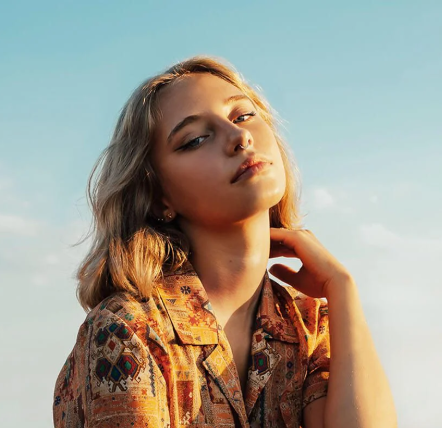

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


a woman in a pink shirt is looking at a picture of a woman in a pink shirt .


In [ ]:
pil_image = Image.open(UPLOADED_FILE)
display(pil_image)
prefix_length=10


# Load CLIP model + GPT2 tokenizer
@hydra.main(config_path="/content/conf", config_name="config", version_base="1.3.2")
def main_test(cfg, fresh_train = True):

    """ fixing randomness """
    set_random_seed(cfg.seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    if cfg.use_torch_compile:
        torch._dynamo.config.cache_size_limit = cfg.compile_dynamo_cache_size_limit

    args = ParserObject()
    assert cfg.mode in args.gpt2_type, f"Expected '{cfg.mode}' mode to be in '{args.gpt2_type}'"

    prefix_length = args.prefix_length
    prefix_dim = 768 # dimension, depends on clip model


    clip_model, preprocess = CLIP()
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

    model = ClipCaptionModel(prefix_length=prefix_length, clip_length=args.prefix_length_clip, prefix_size=prefix_dim,
                              num_layers=args.num_layers, gpt2_type=args.gpt2_type, cfg=cfg)

    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')), strict=False)

    model = model.eval()
    model = model.to('cuda')

    image = preprocess(pil_image).unsqueeze(0).to('cuda')
    with torch.no_grad():
        prefix = clip_model.encode_image(image)
        prefix_embed = model.clip_project(prefix.to(dtype=torch.float32)).reshape(1, prefix_length, -1)

    generated_text_prefix = generate(model, tokenizer, embed=prefix_embed).split('.')[0].strip()+' .'

    print('\n')
    print(generated_text_prefix)

if __name__ == '__main__':
    sys.argv = [
      'placeholder.py',
      'setup=gpt2_69m_cocomix',
    ]
    main_test()

if __name__ == '__main__':
    sys.argv = [
      'placeholder.py',
      'setup=gpt2_69m_ntp',
    ]
    main_test()



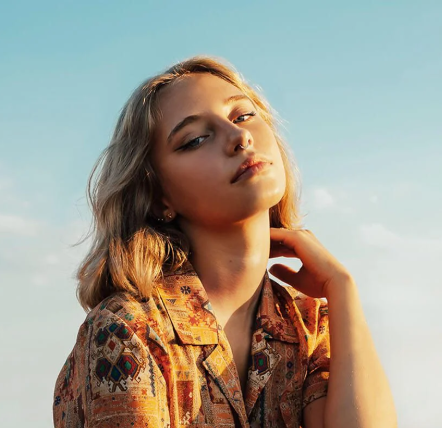

{'cocomix': 75.0, 'ntp': 25.0, 'equal': 0.0, 'cocomix_mean': 0.720703125, 'ntp_mean': 0.279052734375}


In [ ]:
import torch
import clip

# Load CLIP model and tokenizer
device = "cuda"
#clip_model, preprocess = CLIP()

# Dummy data setup
# Suppose you want to test with 4 images
num_samples = 4
UPLOADED_FILE = '/content/image.png'
pil_image = Image.open(UPLOADED_FILE)
display(pil_image)
image = preprocess(pil_image).unsqueeze(0).to('cuda')
with torch.no_grad():
  image_prefix = clip_model.encode_image(image)

# Create dummy image features (normalized random vectors simulating CLIP image embeddings)
prefixes = [image_prefix] * 4
prefixes = [element for element in prefixes for _ in range(5)]

# Create dummy text results, each sample is a list with a single string
result_cocomix = [["a blond girl at sunset"], ["a cat"], ["a car"], ["a mountain"]]
result_ntp = [["a girl"], ["a dog"], ["a bike"], ["a lake"]]

# Make sure the lengths match
assert len(prefixes)/5 == len(result_cocomix) == len(result_ntp)

# Now define your clip_compare function here (or import if you have it elsewhere)

# Run comparison
probs = clip_compare(prefixes, result_cocomix, result_ntp, clip_model)

print(probs)


# Exit

In [ ]:
from google.colab import runtime
import time

# Disconnect runtime when training done
time.sleep(60)
runtime.unassign()